# Phase 1.1: Dataset Preparation - Fusion des Sources Publiques

## Objectif
Fusionner 3 sources de données publiques (EPA AQS, Beijing Multi-Site, UCI Air Quality) vers un schéma canonique unifié.

## Sources de Données
1. **EPA AQS Hourly**: NOx, SOx, PM2.5, PM10, VOC/COV (US) — sans CO/O3
2. **Beijing Multi-Site**: PM2.5, PM10, SO2→SOx, NO2→NOx, NMHC→COV + T/RH (Chine)
3. **UCI Air Quality**: NOx, NO2→NOx, C6H6/NMHC→COV + T/RH (Italie, 2004-2005)

**Polluants cibles**: NOX, SOX, PM25, PM10, CO2 (notebook 03), COV + température/humidité en colonnes.

## Sortie
- `ia/data/raw_merged.csv`: Dataset fusionné brut
- Statistiques de couverture par polluant

## Section 1: Configuration de l'Environnement

In [2]:
# ========================================
# SECTION 1: Import des bibliothèques
# ========================================
# Ces imports sont essentiels pour:
# - pandas: manipulation de données (DataFrames)
# - numpy: opérations numériques
# - matplotlib/seaborn: visualisation des données
# - json: manipulation de fichiers JSON pour métadonnées
# - requests: téléchargement de fichiers depuis URLs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import requests
from pathlib import Path
from datetime import datetime
import urllib.request
import zipfile
import json

# Désactiver les avertissements (warnings) pour une sortie plus claire
warnings.filterwarnings('ignore')

# Configuration style pour les graphiques
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Afficher les versions des packages pour traçabilité
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Pandas version: 3.0.3
NumPy version: 2.4.5


In [3]:
# ========================================
# SECTION 2: Configuration des chemins
# ========================================
# Établir les répertoires où on va lire/écrire les fichiers
# Path(".") = répertoire courant du notebook

PROJECT_ROOT = Path("../").resolve()  # Remonter d'un niveau (ia/)
DATA_DIR = PROJECT_ROOT / "data"      # Répertoire pour les fichiers de données
MODELS_DIR = PROJECT_ROOT / "models"  # Répertoire pour les modèles et résultats

# Créer les répertoires s'ils n'existent pas (ne fait rien si déjà existants)
DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print(f"📁 PROJECT_ROOT: {PROJECT_ROOT}")
print(f"📁 DATA_DIR: {DATA_DIR}")
print(f"📁 MODELS_DIR: {MODELS_DIR}")

📁 PROJECT_ROOT: C:\Users\melik\Desktop\ia
📁 DATA_DIR: C:\Users\melik\Desktop\ia\data
📁 MODELS_DIR: C:\Users\melik\Desktop\ia\models


In [22]:
# ========================================
# SECTION 3: Définition du schéma canonique
# ========================================
# Le "schéma canonique" est le format standard auquel on convertit TOUTES
# les sources de données. Cela permet de combiner EPA, Beijing, UCI facilement.

CANONICAL_SCHEMA = {
    # Identifiants temporels et spatiaux
    'timestamp_utc': 'datetime64[ns]',  # Date/heure en UTC pour traçabilité
    'site_id': 'object',                 # ID unique du site de monitoring
    'site_name': 'object',               # Nom du site (ex: "Beijing_Aotizhongxin")
    
    # Données de polluants et unités
    'pollutant': 'object',               # NO2, SO2, CO, PM25, PM10, CO2, COV, etc.
    'value': 'float64',                  # Valeur mesurée du polluant
    'unit': 'object',                    # mg/m3, mg/Nm3, ppm (Décret 2018-928 / ThresholdConfig)
    
    # Données météorologiques (contexte)
    'temperature_c': 'float64',          # Température en °C
    'humidity_percent': 'float64',       # Humidité relative en %
    'pressure_hpa': 'float64',           # Pression barométrique en hPa
    'wind_speed_ms': 'float64',          # Vitesse du vent en m/s
    
    # Traçabilité des sources
    'source_name': 'object',             # EPA_AQS, Beijing_MultiSite, UCI_AirQuality
    'source_id': 'int64'                 # ID numérique de la source (1, 2, 3)
}

# Polluants cibles — alignés monitoring (NOx, SOx, PM2.5, PM10, CO2, COV) + météo en colonnes
# CO et O3 exclus (non monitorés par le système)
TARGET_POLLUTANTS = ['NOX', 'SOX', 'PM25', 'PM10', 'CO2', 'COV']

# Codes EPA AQS → nom canonique (Parameter Code numérique)
EPA_PARAMETER_CODE_MAP = {
    42602: 'NOX',   # Nitrogen dioxide (NO2)
    42401: 'SOX',   # Sulfur dioxide
    88101: 'PM25',  # PM2.5 FRM/FEM Mass
    81102: 'PM10',  # PM10 Total 0-10um STP
    43000: 'COV',   # Sum of PAMS target compounds (hourly_VOCS)
    43102: 'COV',   # Total NMOC — principal proxy COV dans hourly_VOCS
    43103: 'COV',   # Volatile Organic Compounds (generic)
    43502: 'COV',   # Total NMOC (alternate code)
}

POLLUTANT_ALIASES = {
    'NO2': 'NOX', 'NOX': 'NOX', 'NOx': 'NOX', 'NITROGEN DIOXIDE (NO2)': 'NOX',
    'SO2': 'SOX', 'SOX': 'SOX', 'SULFUR DIOXIDE': 'SOX',
    'PM2.5': 'PM25', 'PM25': 'PM25', 'PM2.5 FRM/FEM MASS': 'PM25',
    'PM10': 'PM10', 'PM10 TOTAL 0-10UM STP': 'PM10',
    'CO2': 'CO2', 'CARBON DIOXIDE': 'CO2',
    'COV': 'COV', 'VOC': 'COV', 'VOCS': 'COV', 'VOCs': 'COV',
    'NMHC': 'COV', 'C6H6': 'COV', 'BENZENE': 'COV',
    'TOTAL NMOC': 'COV', 'VOLATILE ORGANIC COMPOUNDS': 'COV',
}

EXCLUDED_POLLUTANTS = {'CO', 'O3', 'AQI', 'UNKNOWN'}

# Aligné init:thresholds / ThresholdConfig — Décret 2018-928, Annexe 6 (10 % O₂ gaz sec)
# physical max > VLE réglementaire (marge QC capteurs / pics courts)
REGULATORY_LIMITS_REF = {
    'PM25': {'vle': 20, 'warning': 16, 'critical': 24, 'unit': 'mg/m3'},
    'PM10': {'vle': 20, 'warning': 16, 'critical': 24, 'unit': 'mg/m3'},
    'SOX':  {'vle': 400, 'warning': 320, 'critical': 480, 'unit': 'mg/Nm3'},
    'NOX':  {'vle': 800, 'warning': 640, 'critical': 960, 'unit': 'mg/Nm3'},
    'COV':  {'vle': 110, 'warning': 88, 'critical': 132, 'unit': 'mg/Nm3'},
    'CO2':  {'vle': 800, 'warning': 640, 'critical': 960, 'unit': 'ppm'},
}

CANONICAL_UNITS = {pol: REGULATORY_LIMITS_REF[pol]['unit'] for pol in TARGET_POLLUTANTS if pol in REGULATORY_LIMITS_REF}

POLLUTANT_BOUNDS = {
    'PM25': {
        'min': 0, 'max': 50, 'unit': 'mg/m3',
        'regulatory_max': 20, 'warning': 16, 'critical': 24,
        'reference': 'Décret 2018-928 Annexe 6 §I.1 — poussières',
    },
    'PM10': {
        'min': 0, 'max': 80, 'unit': 'mg/m3',
        'regulatory_max': 20, 'warning': 16, 'critical': 24,
        'reference': 'Décret 2018-928 Annexe 6 §I.1 — poussières (PM10)',
    },
    'SOX': {
        'min': 0, 'max': 600, 'unit': 'mg/Nm3',
        'regulatory_max': 400, 'warning': 320, 'critical': 480,
        'reference': 'Décret 2018-928 Annexe 6 §I.2 — SO₂',
    },
    'NOX': {
        'min': 0, 'max': 1500, 'unit': 'mg/Nm3',
        'regulatory_max': 800, 'warning': 640, 'critical': 960,
        'reference': 'Décret 2018-928 Annexe 6 §I.3 — NOₓ (voie sèche + récup.)',
    },
    'COV': {
        'min': 0, 'max': 200, 'unit': 'mg/Nm3',
        'regulatory_max': 110, 'warning': 88, 'critical': 132,
        'reference': 'Indicatif industriel — pas de VLE Annexe 6',
    },
    'CO2': {
        'min': 300, 'max': 5000, 'unit': 'ppm',
        'regulatory_max': 800, 'warning': 640, 'critical': 960,
        'reference': 'Suivi interne KPI — pas de VLE Annexe 6',
    },
}

# Conversion vers unités canoniques (25 °C, gaz idéal : mg/Nm³ = ppb × M / 24,45)
_MW_25C = {'NOX': 46.0, 'SOX': 64.0, 'COV': 44.0}


def _normalize_unit_label(unit):
    if pd.isna(unit):
        return ''
    return str(unit).strip().lower().replace('µ', 'u').replace('μ', 'u').replace('³', '3')


def convert_to_canonical_unit(value, pollutant, from_unit):
    """Convertit une valeur vers l'unité canonique du polluant (si possible)."""
    if pd.isna(value) or pollutant not in CANONICAL_UNITS:
        return value
    target = CANONICAL_UNITS[pollutant]
    src = _normalize_unit_label(from_unit)
    tgt = _normalize_unit_label(target)
    if not src or src == tgt:
        return value
    if src in ('ug/m3', 'ug/nm3') and tgt == 'mg/m3':
        return value / 1000.0
    if src == 'mg/m3' and tgt == 'mg/m3':
        return value
    if src in ('mg/nm3', 'mg/m3') and tgt == 'mg/nm3':
        return value
    if src == 'ppb' and tgt == 'mg/nm3' and pollutant in _MW_25C:
        return value * _MW_25C[pollutant] / 24.45
    if src == 'ppm' and tgt == 'ppm':
        return value
    return value


def harmonize_canonical_units(df):
    """Harmonise value + unit vers REGULATORY_LIMITS_REF / CANONICAL_UNITS."""
    if df.empty or 'pollutant' not in df.columns:
        return df
    out = df.copy()
    src_units = out['unit'] if 'unit' in out.columns else pd.Series(index=out.index, dtype=object)
    out['value'] = [
        convert_to_canonical_unit(v, p, u)
        for v, p, u in zip(out['value'], out['pollutant'], src_units)
    ]
    out['unit'] = out['pollutant'].map(CANONICAL_UNITS)
    return out


def normalize_pollutant_name(name, parameter_code=None):
    """Mappe libellé EPA + code paramètre vers schéma canonique, ou None si exclu."""
    if parameter_code is not None and pd.notna(parameter_code):
        try:
            code = int(parameter_code)
            if code in EPA_PARAMETER_CODE_MAP:
                return EPA_PARAMETER_CODE_MAP[code]
        except (ValueError, TypeError):
            pass
    if pd.isna(name):
        return None
    raw = str(name).strip()
    if raw.isdigit():
        code = int(raw)
        if code in EPA_PARAMETER_CODE_MAP:
            return EPA_PARAMETER_CODE_MAP[code]
        return None
    key = raw.upper().replace('.', '').replace('µ', 'U').replace('Μ', 'U')
    key = ' '.join(key.split())
    if key in EXCLUDED_POLLUTANTS:
        return None
    if 'NMOC' in key or 'NON-METHANE ORGANIC' in key or 'PAMS TARGET' in key:
        return 'COV'
    if key in POLLUTANT_ALIASES:
        return POLLUTANT_ALIASES[key]
    for alias, canon in POLLUTANT_ALIASES.items():
        if alias.replace(' ', '') == key.replace(' ', ''):
            return canon
    return key if key in TARGET_POLLUTANTS else None

print("✅ Schéma canonique défini")
print(f"   Polluants cibles: {', '.join(TARGET_POLLUTANTS)}")
print(f"   Unités canoniques: {CANONICAL_UNITS}")
print(f"   Exclus: {', '.join(sorted(EXCLUDED_POLLUTANTS))}")
print("\n   Bornes physiques (max > VLE Décret 2018-928):")
for pol, b in POLLUTANT_BOUNDS.items():
    print(f"     {pol}: [{b['min']}, {b['max']}] {b['unit']}  (VLE={b['regulatory_max']})")

✅ Schéma canonique défini
   Polluants cibles: NOX, SOX, PM25, PM10, CO2, COV
   Unités canoniques: {'NOX': 'mg/Nm3', 'SOX': 'mg/Nm3', 'PM25': 'mg/m3', 'PM10': 'mg/m3', 'CO2': 'ppm', 'COV': 'mg/Nm3'}
   Exclus: AQI, CO, O3, UNKNOWN

   Bornes physiques (max > VLE Décret 2018-928):
     PM25: [0, 50] mg/m3  (VLE=20)
     PM10: [0, 80] mg/m3  (VLE=20)
     SOX: [0, 600] mg/Nm3  (VLE=400)
     NOX: [0, 1500] mg/Nm3  (VLE=800)
     COV: [0, 200] mg/Nm3  (VLE=110)
     CO2: [300, 5000] ppm  (VLE=800)


## Section 2: Chargement des Données Brutes

In [8]:
# ========================================
# SOURCE A: EPA AQS Hourly Data (USA) - Téléchargement réel
# ========================================
# CRITICAL FIX: Prioritize hourly_sample_measurement (actual measurements)
# not daily AQI summaries

print("🔄 Ingestion EPA AQS (download + map) ...\n")

epa_raw_dir = DATA_DIR / 'epa_raw'
epa_raw_dir.mkdir(parents=True, exist_ok=True)

file_list_url = 'https://aqs.epa.gov/aqsweb/airdata/file_list.csv'

def download_file(url, dest_path):
    if dest_path.exists():
        print(f'↺ Déjà présent: {dest_path.name}')
        return
    print(f'→ Téléchargement: {url}')
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    with open(dest_path, 'wb') as f:
        f.write(r.content)

# Lister les fichiers disponibles chez EPA
try:
    fl = pd.read_csv(file_list_url)
    print(f'file_list téléchargé: {len(fl)} entrées')
    print(f'Colonnes disponibles: {list(fl.columns)}\n')
except Exception as e:
    print('Impossible de récupérer file_list.csv depuis EPA:', e)
    fl = pd.DataFrame()

# **CORRECTED LOGIC**: Prioritize actual measurements over summaries
candidates = []
if not fl.empty:
    names = fl['Filename'].astype(str)
    
    # 2 dernières années par famille de polluant (évite 6× le même VOC)
    import re
    EPA_YEARS_BACK = 2
    target_years = {datetime.now().year - i for i in range(EPA_YEARS_BACK)}
    EPA_FILE_FAMILIES = [
        ('NOX', r'hourly_42602|hourly_no2'),
        ('SOX', r'hourly_42401|hourly_so2'),
        ('PM25', r'hourly_88101|hourly_pm25'),
        ('PM10', r'hourly_81102|hourly_pm10'),
        ('COV', r'hourly_vocs|hourly_43103|hourly_43502|hourly_nmoc'),
    ]

    def _epa_file_year(filename):
        m = re.search(r'_(\d{4})\.zip$', filename, re.IGNORECASE)
        return int(m.group(1)) if m else None

    print("🔍 Recherche EPA: 2 dernières années par polluant (NOx/SOx/PM25/PM10/COV)...\n")
    print(f"   Années cibles: {sorted(target_years, reverse=True)}\n")

    mask_hourly = names.str.contains('hourly_', case=False, na=False)
    mask_not_aqi = ~names.str.contains('aqi', case=False, na=False)
    mask_not_co = ~names.str.contains('hourly_44201|co_by', case=False, na=False)
    mask_not_spec = ~names.str.contains('pm10spec|pm25spec', case=False, na=False)
    eligible = names[mask_hourly & mask_not_aqi & mask_not_co & mask_not_spec]

    candidates = []
    for family_label, pattern in EPA_FILE_FAMILIES:
        family_files = eligible[eligible.str.contains(pattern, case=False, regex=True, na=False)]
        picked = []
        for fn in family_files:
            year = _epa_file_year(fn)
            if year in target_years:
                picked.append((year, fn))
        picked.sort(key=lambda x: x[0], reverse=True)
        for year, fn in picked[:EPA_YEARS_BACK]:
            if fn not in candidates:
                candidates.append(fn)
        if picked:
            print(f"  {family_label}: {[fn for _, fn in picked[:EPA_YEARS_BACK]]}")
        else:
            print(f"  {family_label}: (aucun fichier pour {sorted(target_years)})")

    if not candidates:
        mask_pollutant = names.str.contains('conc_by_monitor|42602|42401|88101', case=False, na=False)
        fallback = eligible[eligible.str.contains('conc_by_monitor|42602|42401|88101', case=False, na=False)].tolist()
        for fn in sorted(fallback, reverse=True):
            year = _epa_file_year(fn)
            if year in target_years and fn not in candidates:
                candidates.append(fn)
        print(f'\n⚠️  Fallback: {len(candidates)} fichiers EPA génériques')

    print(f'\n✅ {len(candidates)} fichiers EPA à télécharger (max {EPA_YEARS_BACK} ans × {len(EPA_FILE_FAMILIES)} polluants)')
    for i, c in enumerate(candidates, 1):
        print(f'  {i}. {c}')
    print()

# Télécharger et extraire
epa_dfs = []
download_count = 0

for fn in candidates:
    try:
        url = 'https://aqs.epa.gov/aqsweb/airdata/' + fn
        dest = epa_raw_dir / fn
        download_file(url, dest)
        download_count += 1
        
        # Extraire CSV(s) du zip et charger
        if dest.suffix.lower() == '.zip':
            with zipfile.ZipFile(dest, 'r') as z:
                for name in z.namelist():
                    if name.lower().endswith('.csv'):
                        with z.open(name) as f:
                            try:
                                df = pd.read_csv(f, low_memory=False)
                                col_summary = f"{len(df)} lignes × {len(df.columns)} colonnes"
                                print(f'  ✓ Extrait: {name}: {col_summary}')
                                epa_dfs.append(df)
                            except Exception as e:
                                print(f'  ✗ Erreur lecture CSV: {name} - {type(e).__name__}')
    except Exception as e:
        print(f'  ✗ Échec: {fn} ({type(e).__name__})')

# Concaténer si des frames ont été chargés
if epa_dfs:
    epa_raw = pd.concat(epa_dfs, ignore_index=True, sort=False)
    print(f'\n✅ EPA raw chargé: {len(epa_raw)} lignes depuis {download_count} fichiers')
else:
    epa_raw = pd.DataFrame()
    print('\n⚠️ Aucun fichier EPA chargé')

# Mapper vers schéma canonique
def map_epa_to_canonical(df):
    """Map EPA AQS columns to canonical schema - gérer multiple format types"""
    if df.empty:
        print("  ℹ️  DataFrame vide, retour DataFrame vide")
        return pd.DataFrame()
    
    df2 = df.copy()
    
    # Afficher les colonnes pour debug
    available_cols = list(df2.columns)
    print(f"  Colonnes EPA: {available_cols[:8]}{'...' if len(available_cols) > 8 else ''}")
    
    # Tenter mapping selon format détecté
    result = pd.DataFrame()
    
    # Format 0: EPA AQS standard hourly (Parameter Name, Sample Measurement, Date Local)
    if 'Sample Measurement' in df2.columns and 'Parameter Name' in df2.columns:
        print("  → Format détecté: EPA AQS hourly standard ✅")
        result = df2.copy()
        result['timestamp_utc'] = pd.to_datetime(
            result.get('Date Local', pd.NaT).astype(str) + ' ' + result.get('Time Local', '00:00').astype(str),
            errors='coerce'
        )
        result['value'] = pd.to_numeric(result['Sample Measurement'], errors='coerce')
        result['pollutant'] = result['Parameter Name']
        result['parameter_code'] = result.get('Parameter Code')
        # hourly_VOCS: garder NMOC / PAMS (pas chaque espèce 432xx → doublons)
        if 'Parameter Name' in result.columns:
            voc_species = result['Parameter Name'].astype(str).str.contains(
                r'NMOC|PAMS target|non-methane organic', case=False, na=False, regex=True
            )
            if voc_species.any() and (~voc_species).any():
                n_before = len(result)
                result = result[voc_species].copy()
                print(f"  → VOC: conservé NMOC/PAMS uniquement ({len(result):,} / {n_before:,} lignes)")
        result['unit'] = result.get('Units of Measure', 'ppb')
        sc = result.get('State Code', '').astype(str)
        cc = result.get('County Code', '').astype(str)
        sn = result.get('Site Num', '').astype(str)
        result['site_id'] = (sc + '_' + cc + '_' + sn).str.strip('_')
        result['site_name'] = result.get('County Name', result.get('State Name', result['site_id']))
    
    # Format 1: hourly_sample_measurement (colonnes: date_observed, site_id, parameter_name, sample_measurement, etc.)
    elif 'sample_measurement' in [c.lower() for c in df2.columns]:
        print("  → Format détecté: hourly_sample_measurement ✅")
        df2.columns = [c.lower() for c in df2.columns]
        # Mapper colonnes
        result = df2.copy() if all(c in df2.columns for c in ['date_observed', 'sample_measurement']) else pd.DataFrame()
        if not result.empty:
            # Parser timestamps and values
            result['timestamp_utc'] = pd.to_datetime(result.get('date_observed', pd.NaT), errors='coerce')
            result['value'] = pd.to_numeric(result.get('sample_measurement', np.nan), errors='coerce')
            result['pollutant'] = result.get('parameter_name', 'Unknown')
            result['unit'] = result.get('units_of_measure', 'ppb')
            result['site_id'] = result.get('site_num', 'EPA_site')
            result['site_name'] = result.get('site_num', 'EPA_site')
    
    # Format 2: AQI data (colonnes: Date, AQI, Defining Parameter, etc.)
    elif 'AQI' in df2.columns and 'Defining Parameter' in df2.columns:
        print("  → Format détecté: AQI summary (⚠️ not ideal)")
        result = df2[['Date', 'AQI', 'Defining Parameter', 'State Name', 'county Name']].copy()
        result.rename(columns={'Date': 'timestamp_utc', 'AQI': 'value', 'Defining Parameter': 'pollutant', 'State Name': 'site_name'}, inplace=True)
    
    # Format 3: conc_by_monitor (annual/daily concentration data)
    elif any(c in df2.columns for c in ['1st Max Value', 'Arithmetic Mean', 'Median']):
        print("  → Format détecté: concentration summary")
        # Try to extract meaningful columns
        result = df2.copy()
        for val_col in ['1st Max Value', 'Arithmetic Mean', 'Median']:
            if val_col in result.columns:
                result['value'] = pd.to_numeric(result[val_col], errors='coerce')
                break
        result['timestamp_utc'] = pd.to_datetime(result.get('Date', pd.NaT), errors='coerce')
        result['pollutant'] = result.get('Parameter Name', 'Unknown')
        result['site_id'] = result.get('Site ID', 'EPA_site')
        result['site_name'] = result.get('Site Name', 'EPA_site')
        result['unit'] = result.get('Units of Measure', 'ppb')
    
    # Format 4: Generic format search
    else:
        print("  → Tentative format générique...")
        date_cols = [c for c in df2.columns if any(k in c.lower() for k in ['date', 'time', 'observed'])]
        val_cols = [c for c in df2.columns if any(k in c.lower() for k in ['value', 'concentration', 'measurement', 'mean'])]
        pol_cols = [c for c in df2.columns if any(k in c.lower() for k in ['parameter', 'pollutant', 'compound'])]
        
        if date_cols and val_cols:
            result = df2[[date_cols[0], val_cols[0]]].copy()
            result.columns = ['timestamp_utc', 'value']
            if pol_cols:
                result['pollutant'] = df2[pol_cols[0]]
        else:
            print(f"  ⚠️  Impossible de mapper — colonnes non reconnues")
            return pd.DataFrame()
    
    # Ajouter métadonnées obligatoires
    if not result.empty:
        result['site_id'] = result.get('site_id', 'EPA_default')
        result['site_name'] = result.get('site_name', 'EPA_default')
        result['pollutant'] = result.get('pollutant', 'Unknown').fillna('Unknown')
        result['unit'] = result.get('unit', 'ppb')
        result['timestamp_utc'] = pd.to_datetime(result.get('timestamp_utc', pd.NaT), errors='coerce')
        result['value'] = pd.to_numeric(result.get('value', np.nan), errors='coerce')
        
        result['source_name'] = 'EPA_AQS'
        result['source_id'] = 1
    
    return result

epa_df = map_epa_to_canonical(epa_raw)

if not epa_df.empty:
    valid_cols = [c for c in ['pollutant', 'value', 'timestamp_utc'] if c in epa_df.columns]
    epa_df = epa_df.dropna(subset=valid_cols, how='any')
    if 'parameter_code' in epa_df.columns:
        epa_df['pollutant'] = epa_df.apply(
            lambda r: normalize_pollutant_name(r['pollutant'], r.get('parameter_code')), axis=1
        )
    else:
        epa_df['pollutant'] = epa_df['pollutant'].apply(normalize_pollutant_name)
    epa_df = epa_df[epa_df['pollutant'].isin(TARGET_POLLUTANTS)]
    epa_df = epa_df.drop(columns=['parameter_code'], errors='ignore')
    epa_df = epa_df.dropna(subset=['value'])
    print(f"\n✅ EPA mappé: {len(epa_df):,} lignes valides (polluants cibles)")
    print(f"   Polluants: {sorted(epa_df['pollutant'].unique().tolist())}")
else:
    print('\n⚠️ EPA non mappé — données non reconnaissables')
    epa_df = pd.DataFrame()

🔄 Ingestion EPA AQS (download + map) ...

file_list téléchargé: 2005 entrées
Colonnes disponibles: ['Filename', 'Rows', 'Size', 'Created']

🔍 Recherche EPA: 2 dernières années par polluant (NOx/SOx/PM25/PM10/COV)...

   Années cibles: [2026, 2025]

  NOX: ['hourly_42602_2025.zip']
  SOX: ['hourly_42401_2025.zip']
  PM25: ['hourly_88101_2025.zip']
  PM10: ['hourly_81102_2025.zip']
  COV: ['hourly_VOCS_2025.zip']

✅ 5 fichiers EPA à télécharger (max 2 ans × 5 polluants)
  1. hourly_42602_2025.zip
  2. hourly_42401_2025.zip
  3. hourly_88101_2025.zip
  4. hourly_81102_2025.zip
  5. hourly_VOCS_2025.zip

→ Téléchargement: https://aqs.epa.gov/aqsweb/airdata/hourly_42602_2025.zip
  ✓ Extrait: hourly_42602_2025.csv: 2177852 lignes × 24 colonnes
→ Téléchargement: https://aqs.epa.gov/aqsweb/airdata/hourly_42401_2025.zip
  ✓ Extrait: hourly_42401_2025.csv: 1883323 lignes × 24 colonnes
→ Téléchargement: https://aqs.epa.gov/aqsweb/airdata/hourly_88101_2025.zip
  ✓ Extrait: hourly_88101_2025.csv: 5

In [13]:
# ========================================
# SOURCE B: Beijing Multi-Site Air Quality Data - Téléchargement + Synthétique
# ========================================
# Dataset: Beijing Multi-Site Air Quality (2013-2017)
# Sources alternatives: UCI ML Repository, Kaggle, GitHub, ou synthétique
# Polluants: PM2.5, PM10, SO2, NO2, CO, O3 + météo

print("🔄 Ingestion Beijing Multi-Site ...\n")

beijing_raw_dir = DATA_DIR / 'beijing_raw'
beijing_raw_dir.mkdir(parents=True, exist_ok=True)

# URLs candidates (par ordre de préférence)
beijing_urls = [
    'https://raw.githubusercontent.com/serengp/AirQualityUCI/master/AirQualityUCI.csv',  # Alternative 1
    'https://archive.ics.uci.edu/ml/machine-learning-databases/00501/PRSA_data_2010.1.1-14.12.31.zip',  # Alternative 2 (peut être obsolète)
]

beijing_df = pd.DataFrame()

# Tenter téléchargement depuis les URLs
for url in beijing_urls:
    print(f'→ Tentative: {url}')
    try:
        if url.endswith('.zip'):
            dest = beijing_raw_dir / Path(url).name
            if not dest.exists():
                r = requests.get(url, timeout=60)
                r.raise_for_status()
                with open(dest, 'wb') as f:
                    f.write(r.content)
            
            with zipfile.ZipFile(dest, 'r') as z:
                for name in z.namelist():
                    if name.lower().endswith('.csv'):
                        with z.open(name) as f:
                            tmp = pd.read_csv(f, low_memory=False)
                            beijing_df = pd.concat([beijing_df, tmp], ignore_index=True)
                            print(f'  ✓ Extrait: {name} ({len(tmp)} lignes)')
        else:
            # CSV direct
            tmp = pd.read_csv(url, low_memory=False)
            beijing_df = tmp.copy()
            print(f'  ✓ Chargé: {len(tmp)} lignes × {len(tmp.columns)} colonnes')
        
        if not beijing_df.empty:
            print(f'✅ Beijing téléchargé: {len(beijing_df)} lignes')
            break
    except Exception as e:
        print(f'  ✗ Échec: {type(e).__name__}')
        continue

# Fallback: Générer données synthétiques Beijing si téléchargement échoue
if beijing_df.empty:
    print('\n⚠️ Téléchargement Beijing échoué — génération de données synthétiques pour démo\n')
    
    # Générer données synthétiques réalistes (Beijing-like)
    np.random.seed(42)
    
    n_rows = 8760 * 3  # 3 ans de données horaires
    beijing_df = pd.DataFrame({
        'year': np.random.choice([2015, 2016, 2017], n_rows),
        'month': np.random.choice(range(1, 13), n_rows),
        'day': np.random.choice(range(1, 29), n_rows),
        'hour': np.random.choice(range(0, 24), n_rows),
        'station': np.random.choice(['Aotizhongxin', 'Changping', 'Chaoyang', 'Dongsi', 'Guanyuan'], n_rows),
        'PM2.5': np.random.gamma(shape=50, scale=2, size=n_rows),  # Pollution forte
        'PM10': np.random.gamma(shape=60, scale=2.5, size=n_rows),
        'SO2': np.random.exponential(scale=10, size=n_rows),
        'NO2': np.random.normal(loc=40, scale=15, size=n_rows).clip(0),
        'TEMP': np.random.normal(loc=15, scale=10, size=n_rows),
        'NMHC': np.random.exponential(scale=50, size=n_rows),  # proxy COV
        'RH': np.random.normal(loc=65, scale=15, size=n_rows).clip(0, 100),
        'PRES': np.random.normal(loc=1013, scale=5, size=n_rows)
    })
    
    print(f'✅ Données synthétiques Beijing générées: {len(beijing_df)} lignes')
    beijing_df['synthetic'] = True
else:
    beijing_df['synthetic'] = False

print(f"   Colonnes: {list(beijing_df.columns)[:8]}...")

# Mapper Beijing vers schéma canonique
def map_beijing_to_canonical(df):
    """Map Beijing Multi-Site columns to canonical schema"""
    if df.empty:
        print("  ℹ️  DataFrame vide")
        return pd.DataFrame()
    
    df2 = df.copy()
    print(f"  Colonnes Beijing: {list(df2.columns)[:8]}...")
    
    # Le dataset Beijing (UCI ou synthétique) a:
    # year, month, day, hour, station, PM2.5, PM10, SO2, NO2, CO, O3, TEMP, RH, PRES
    
    # Créer timestamp
    if all(c in df2.columns for c in ['year', 'month', 'day', 'hour']):
        try:
            df2['timestamp_utc'] = pd.to_datetime(
                df2[['year', 'month', 'day', 'hour']].astype(str).agg('-'.join, axis=1),
                format='%Y-%m-%d-%H',
                errors='coerce'
            )
            print(f"  → Timestamp créé: year/month/day/hour")
        except Exception as e:
            print(f"  ✗ Erreur timestamp: {e}")
            df2['timestamp_utc'] = pd.NaT
    else:
        df2['timestamp_utc'] = pd.NaT
    
    # Site ID et Name
    if 'station' in [c.lower() for c in df2.columns]:
        station_col = [c for c in df2.columns if c.lower() == 'station'][0]
        df2['site_id'] = df2[station_col].astype(str)
        df2['site_name'] = df2[station_col].astype(str)
    else:
        df2['site_id'] = 'Beijing_MultiSite'
        df2['site_name'] = 'Beijing_MultiSite'
    
    # Transformer en format long (1 ligne = 1 polluant)
    # Polluants cibles uniquement (pas CO/O3)
    beijing_pollutant_map = {
        'PM2.5': ('PM25', 'ug/m3'),
        'PM10': ('PM10', 'ug/m3'),
        'SO2': ('SOX', 'ppb'),
        'NO2': ('NOX', 'ppb'),
        'NMHC': ('COV', 'ppb'),
        'C6H6': ('COV', 'ppb'),
    }
    long_data = []
    
    for src_col, (canon, unit) in beijing_pollutant_map.items():
        pol_col = next((c for c in df2.columns if src_col.replace('.', '') in c.replace('.', '')), None)
        
        if pol_col and pol_col in df2.columns:
            subset = df2[['timestamp_utc', 'site_id', 'site_name', pol_col]].copy()
            subset.columns = ['timestamp_utc', 'site_id', 'site_name', 'value']
            subset['pollutant'] = canon
            subset['unit'] = unit
            
            # Ajouter météo
            if 'TEMP' in df2.columns:
                subset['temperature_c'] = df2['TEMP'].values
            if 'RH' in df2.columns:
                subset['humidity_percent'] = df2['RH'].values
            if 'PRES' in df2.columns:
                subset['pressure_hpa'] = df2['PRES'].values
            
            long_data.append(subset)
    
    if long_data:
        result = pd.concat(long_data, ignore_index=True)
        
        # Ajouter métadonnées
        result['source_name'] = 'Beijing_MultiSite'
        result['source_id'] = 2
        result['wind_speed_ms'] = np.nan  # Non disponible
        
        # Marquer si synthétique
        if 'synthetic' in df2.columns:
            result['synthetic'] = df2['synthetic'].iloc[0]
        else:
            result['synthetic'] = False
        
        return result
    else:
        print(f"  ⚠️  Aucun polluant trouvé")
        return pd.DataFrame()

beijing_canonical = map_beijing_to_canonical(beijing_df)

if not beijing_canonical.empty:
    beijing_canonical = beijing_canonical.dropna(subset=['value'], how='any')
    beijing_canonical['pollutant'] = beijing_canonical['pollutant'].apply(normalize_pollutant_name)
    beijing_canonical = beijing_canonical[beijing_canonical['pollutant'].isin(TARGET_POLLUTANTS)]
    synthetic_flag = "SYNTHÉTIQUE" if beijing_canonical['synthetic'].iloc[0] else ""
    print(f"\n✅ Beijing mappé: {len(beijing_canonical)} lignes {synthetic_flag}")
    print(f"   Polluants: {sorted(beijing_canonical['pollutant'].unique().tolist())}")
    print(f"   Période: {beijing_canonical['timestamp_utc'].min()} à {beijing_canonical['timestamp_utc'].max()}")
else:
    beijing_canonical = pd.DataFrame()
    print('\n⚠️ Beijing non mappé')

🔄 Ingestion Beijing Multi-Site ...

→ Tentative: https://raw.githubusercontent.com/serengp/AirQualityUCI/master/AirQualityUCI.csv
  ✗ Échec: HTTPError
→ Tentative: https://archive.ics.uci.edu/ml/machine-learning-databases/00501/PRSA_data_2010.1.1-14.12.31.zip
  ✗ Échec: HTTPError

⚠️ Téléchargement Beijing échoué — génération de données synthétiques pour démo

✅ Données synthétiques Beijing générées: 26280 lignes
   Colonnes: ['year', 'month', 'day', 'hour', 'station', 'PM2.5', 'PM10', 'SO2']...
  Colonnes Beijing: ['year', 'month', 'day', 'hour', 'station', 'PM2.5', 'PM10', 'SO2']...
  → Timestamp créé: year/month/day/hour

✅ Beijing mappé: 131400 lignes SYNTHÉTIQUE
   Polluants: ['COV', 'NOX', 'PM10', 'PM25', 'SOX']
   Période: 2015-01-01 00:00:00 à 2017-12-28 22:00:00


In [10]:
# ========================================
# SOURCE C: UCI Air Quality Dataset (Padova) - Téléchargement réel
# ========================================
# URL officiel UCI (AirQualityUCI): https://archive.ics.uci.edu/ml/machine-learning-databases/00360/

print("🔄 Ingestion UCI AirQualityUCI (Padova) ...\n")

uci_raw_dir = DATA_DIR / 'uci_raw'
uci_raw_dir.mkdir(parents=True, exist_ok=True)

uci_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip'

def download_and_extract_zip(url, dest_dir):
    dest = dest_dir / Path(url).name
    if not dest.exists():
        print(f'→ Téléchargement: {url}')
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        with open(dest, 'wb') as f:
            f.write(r.content)
    else:
        print(f'↺ Déjà présent: {dest.name}')
    # Extraire et tenter de repérer un CSV
    dfs = []
    try:
        with zipfile.ZipFile(dest, 'r') as z:
            for name in z.namelist():
                if name.lower().endswith('.csv') or name.lower().endswith('.txt'):
                    with z.open(name) as f:
                        try:
                            tmp = pd.read_csv(f, sep=';', decimal=',', low_memory=False)
                            dfs.append(tmp)
                        except Exception as e:
                            try:
                                tmp = pd.read_csv(f, low_memory=False)
                                dfs.append(tmp)
                            except Exception as e2:
                                print('Erreur lecture UCI file inside zip:', e2)
    except Exception as e:
        print('Erreur extraction UCI zip:', e)
    return pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()

uci_df = download_and_extract_zip(uci_url, uci_raw_dir)
if not uci_df.empty:
    print(f'✅ UCI raw chargé: {len(uci_df)} lignes — colonnes: {list(uci_df.columns)[:10]}')
    # Tentative de mappage vers schéma canonique (adapter selon structure du CSV)
    # Exemple basique: certaines colonnes du dataset UCI utilisent séparateurs et décimales locales
    # L'utilisateur devra valider les colonnes effectivement présentes et ajuster le mapping si nécessaire.
else:
    print('⚠️ UCI AirQualityUCI non téléchargé automatiquement — vérifier URL ou connexion')

🔄 Ingestion UCI AirQualityUCI (Padova) ...

→ Téléchargement: https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
✅ UCI raw chargé: 9471 lignes — colonnes: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)']


## Section 3: Transformation vers Schéma Canonique

In [14]:
# Transformation EPA → schéma canonique
# Note: Déjà effectuée partiellement dans map_epa_to_canonical()

print("🔄 Finalisation EPA transformé...\n")

if not epa_df.empty:
    # Vérifier que toutes les colonnes requises sont présentes
    required_cols = ['timestamp_utc', 'site_id', 'pollutant', 'value', 'unit', 'source_name', 'source_id']
    missing = [c for c in required_cols if c not in epa_df.columns]
    
    if missing:
        print(f"⚠️  Colonnes manquantes: {missing}")
        # Ajouter les colonnes manquantes
        for col in missing:
            epa_df[col] = np.nan
    
    # Ajouter site_name si absent
    if 'site_name' not in epa_df.columns:
        epa_df['site_name'] = epa_df['site_id']
    
    # Ajouter colonnes météo si absentes
    for col in ['temperature_c', 'humidity_percent', 'pressure_hpa', 'wind_speed_ms']:
        if col not in epa_df.columns:
            epa_df[col] = np.nan
    
    # Assurer les types corrects
    epa_df['timestamp_utc'] = pd.to_datetime(epa_df['timestamp_utc'], errors='coerce')
    epa_df['value'] = pd.to_numeric(epa_df['value'], errors='coerce')
    
    epa_canonical = epa_df.copy()
    
    print(f"✅ EPA canonicalisé: {len(epa_canonical)} lignes")
    print(f"\nAperçu:")
    print(epa_canonical.head(10))
else:
    epa_canonical = pd.DataFrame()
    print("ℹ️  EPA pas disponible — utilisation d'un DataFrame vide")

🔄 Finalisation EPA transformé...

✅ EPA canonicalisé: 11619614 lignes

Aperçu:
   State Code  County Code  Site Num  Parameter Code  POC   Latitude  \
0           1           73        23           42602    1  33.553056   
1           1           73        23           42602    1  33.553056   
2           1           73        23           42602    1  33.553056   
3           1           73        23           42602    1  33.553056   
4           1           73        23           42602    1  33.553056   
5           1           73        23           42602    1  33.553056   
6           1           73        23           42602    1  33.553056   
7           1           73        23           42602    1  33.553056   
8           1           73        23           42602    1  33.553056   
9           1           73        23           42602    1  33.553056   

   Longitude  Datum          Parameter Name  Date Local  ... pollutant  \
0    -86.815  WGS84  Nitrogen dioxide (NO2)  2025-01-1

In [15]:
# Transformation Beijing → schéma canonique
# Note: Déjà effectuée dans la cellule d'ingestion précédente

print("🔄 Finalisation Beijing canonicalisé...\n")

if not beijing_canonical.empty:
    # Vérifier et ajouter colonnes manquantes
    required_cols = ['timestamp_utc', 'site_id', 'site_name', 'pollutant', 'value', 'unit', 'source_name', 'source_id']
    missing = [c for c in required_cols if c not in beijing_canonical.columns]
    
    if missing:
        print(f"⚠️  Colonnes manquantes ajoutées: {missing}")
        for col in missing:
            beijing_canonical[col] = np.nan
    
    # Assurer les types corrects
    beijing_canonical['timestamp_utc'] = pd.to_datetime(beijing_canonical['timestamp_utc'], errors='coerce')
    beijing_canonical['value'] = pd.to_numeric(beijing_canonical['value'], errors='coerce')
    
    # Ajouter colonnes météo optionnelles si absentes
    for col in ['temperature_c', 'humidity_percent', 'pressure_hpa', 'wind_speed_ms']:
        if col not in beijing_canonical.columns:
            beijing_canonical[col] = np.nan
    
    # Marquer flag synthétique si absent
    if 'synthetic' not in beijing_canonical.columns:
        beijing_canonical['synthetic'] = False
    
    print(f"✅ Beijing canonicalisé: {len(beijing_canonical)} lignes")
    print(f"\nStatistiques:")
    print(f"   Sites: {beijing_canonical['site_name'].nunique()}")
    print(f"   Polluants: {sorted(beijing_canonical['pollutant'].unique().tolist())}")
    print(f"   Synthétique: {beijing_canonical['synthetic'].sum()} lignes ({beijing_canonical['synthetic'].sum()/len(beijing_canonical)*100:.1f}%)")
    print(f"\nAperçu:")
    print(beijing_canonical.head(10))
else:
    print("ℹ️  Beijing pas disponible — utilisation d'un DataFrame vide")

🔄 Finalisation Beijing canonicalisé...

✅ Beijing canonicalisé: 131400 lignes

Statistiques:
   Sites: 5
   Polluants: ['COV', 'NOX', 'PM10', 'PM25', 'SOX']
   Synthétique: 131400 lignes (100.0%)

Aperçu:
        timestamp_utc       site_id     site_name       value pollutant  \
0 2017-02-04 00:00:00      Chaoyang      Chaoyang   98.117298      PM25   
1 2015-12-27 18:00:00        Dongsi        Dongsi   81.048570      PM25   
2 2017-10-06 00:00:00      Chaoyang      Chaoyang  100.562806      PM25   
3 2017-02-11 23:00:00      Guanyuan      Guanyuan  114.524153      PM25   
4 2015-04-12 23:00:00        Dongsi        Dongsi  112.342446      PM25   
5 2015-02-24 03:00:00     Changping     Changping  116.811264      PM25   
6 2017-07-28 23:00:00      Guanyuan      Guanyuan   89.916096      PM25   
7 2016-12-09 06:00:00  Aotizhongxin  Aotizhongxin  100.751890      PM25   
8 2017-10-18 19:00:00      Guanyuan      Guanyuan   93.545621      PM25   
9 2017-01-17 00:00:00      Guanyuan      Guan

In [16]:
# Transformation UCI → schéma canonique

print("🔄 Transformation UCI Air Quality (Padova)...\n")

if uci_df.empty:
    print("ℹ️  UCI DataFrame vide")
    uci_canonical = pd.DataFrame()
else:
    print(f"UCI shape: {uci_df.shape}")
    print(f"Sample data:")
    print(f"  Date: {uci_df['Date'].iloc[0]} (type: {type(uci_df['Date'].iloc[0])})")
    print(f"  Time: {uci_df['Time'].iloc[0]} (type: {type(uci_df['Time'].iloc[0])})")
    
    uci_work = uci_df.copy()
    
    # Créer timestamp - adapter au format réel: DD/MM/YYYY et HH.MM.SS
    try:
        # Format: 10/03/2004 18.00.00 (ou D.M.YYYY H.M.S)
        date_str = uci_work['Date'].astype(str)
        time_str = uci_work['Time'].astype(str)
        
        # Essayer différents formats
        timestamp_candidates = [
            pd.to_datetime(date_str + ' ' + time_str, format='%d/%m/%Y %H.%M.%S', errors='coerce'),
            pd.to_datetime(date_str + ' ' + time_str, format='%d.%m.%Y %H.%M.%S', errors='coerce'),
            pd.to_datetime(date_str.str.replace('.', '/') + ' ' + time_str, format='%d/%m/%Y %H.%M.%S', errors='coerce'),
        ]
        
        # Prendre le format qui donne le plus de timestamps valides
        valid_counts = [ts.notna().sum() for ts in timestamp_candidates]
        best_idx = valid_counts.index(max(valid_counts))
        uci_work['timestamp_utc'] = timestamp_candidates[best_idx]
        
        n_valid = uci_work['timestamp_utc'].notna().sum()
        print(f"✓ Timestamp créé: {n_valid} valides sur {len(uci_work)}")
    except Exception as e:
        print(f"✗ Erreur timestamp: {e}")
        uci_work['timestamp_utc'] = pd.NaT
    
    # Site info
    uci_work['site_id'] = 'Padova_UCI'
    uci_work['site_name'] = 'Padova, Italy'
    
    # Transformer en format long
    pollutant_cols = {
        'NOx(GT)': {'canon': 'NOX', 'unit': 'ppb'},
        'NO2(GT)': {'canon': 'NOX', 'unit': 'ppb'},
        'C6H6(GT)': {'canon': 'COV', 'unit': 'ug/m3'},
        'NMHC(GT)': {'canon': 'COV', 'unit': 'ppb'},
    }
    
    long_data = []
    
    for uci_col, pol_info in pollutant_cols.items():
        if uci_col not in uci_work.columns:
            print(f"⚠️  Colonne {uci_col} non trouvée")
            continue
        
        # Créer subset pour ce polluant
        subset = uci_work[['timestamp_utc', 'site_id', 'site_name', uci_col]].copy()
        subset.columns = ['timestamp_utc', 'site_id', 'site_name', 'value']
        subset['pollutant'] = pol_info['canon']
        subset['unit'] = pol_info['unit']
        
        # Ajouter météo si présente
        subset['temperature_c'] = uci_work['T'].values if 'T' in uci_work.columns else np.nan
        subset['humidity_percent'] = uci_work['RH'].values if 'RH' in uci_work.columns else np.nan
        subset['pressure_hpa'] = np.nan
        subset['wind_speed_ms'] = np.nan
        
        # Filtrer:
        # 1. Valeurs >= 0 (UCI codes manquantes comme -200.0)
        # 2. Timestamps valides
        valid_mask = (subset['value'] >= 0) & (subset['timestamp_utc'].notna())
        subset = subset[valid_mask].copy()
        
        n_valid = len(subset)
        print(f"{'✓' if n_valid > 0 else '✗'} {uci_col}: {n_valid} lignes")
        
        if n_valid > 0:
            long_data.append(subset)
    
    if long_data:
        uci_canonical = pd.concat(long_data, ignore_index=True, sort=False)
        
        # Ajouter métadonnées
        uci_canonical['source_name'] = 'UCI_AirQuality'
        uci_canonical['source_id'] = 3
        uci_canonical['synthetic'] = False
        uci_canonical['pollutant'] = uci_canonical['pollutant'].apply(normalize_pollutant_name)
        uci_canonical = uci_canonical[uci_canonical['pollutant'].isin(TARGET_POLLUTANTS)]
        uci_canonical = (
            uci_canonical.groupby(
                ['timestamp_utc', 'site_id', 'site_name', 'pollutant', 'unit',
                 'source_name', 'source_id', 'synthetic'],
                as_index=False
            )
            .agg({'value': 'mean', 'temperature_c': 'first', 'humidity_percent': 'first',
                  'pressure_hpa': 'first', 'wind_speed_ms': 'first'})
        )
        
        print(f"\n✅ UCI transformé: {len(uci_canonical)} lignes")
        print(f"   Polluants: {sorted(uci_canonical['pollutant'].unique().tolist())}")
        print(f"   Période: {uci_canonical['timestamp_utc'].min():.0f} → {uci_canonical['timestamp_utc'].max():.0f}")
        print(f"\nAperçu:")
        print(uci_canonical.head(5))
    else:
        print("⚠️  Pas de données valides")
        uci_canonical = pd.DataFrame()

🔄 Transformation UCI Air Quality (Padova)...

UCI shape: (9471, 17)
Sample data:
  Date: 10/03/2004 (type: <class 'str'>)
  Time: 18.00.00 (type: <class 'str'>)
✓ Timestamp créé: 9357 valides sur 9471
✓ NOx(GT): 7718 lignes
✓ NO2(GT): 7715 lignes
✓ C6H6(GT): 8991 lignes
✓ NMHC(GT): 914 lignes

✅ UCI transformé: 17623 lignes
   Polluants: ['COV', 'NOX']
   Période: .0f → .0f

Aperçu:
        timestamp_utc     site_id      site_name pollutant   unit  \
0 2004-03-10 18:00:00  Padova_UCI  Padova, Italy       COV    ppb   
1 2004-03-10 18:00:00  Padova_UCI  Padova, Italy       COV  ug/m3   
2 2004-03-10 18:00:00  Padova_UCI  Padova, Italy       NOX    ppb   
3 2004-03-10 19:00:00  Padova_UCI  Padova, Italy       COV    ppb   
4 2004-03-10 19:00:00  Padova_UCI  Padova, Italy       COV  ug/m3   

      source_name  source_id  synthetic  value  temperature_c  \
0  UCI_AirQuality          3      False  150.0           13.6   
1  UCI_AirQuality          3      False   11.9           13.6   
2  U

## Section 4: Fusion et Normalisation

In [17]:
# Fusionner tous les datasets

print("🔄 Fusion des 3 sources...\n")

# S'assurer que toutes les colonnes du schéma canonique sont présentes
all_dfs = [df for df in [epa_canonical, beijing_canonical, uci_canonical] if not df.empty]

if not all_dfs:
    print("❌ ERREUR: Aucun dataset valide disponible!")
    print("Vérifier l'ingestion des sources: EPA, Beijing, UCI")
    merged_df = pd.DataFrame()
else:
    # Ajouter colonnes manquantes à chaque DataFrame
    for df in all_dfs:
        for col in CANONICAL_SCHEMA.keys():
            if col not in df.columns:
                df[col] = np.nan
    
    # Concaténer
    merged_df = pd.concat(all_dfs, ignore_index=True, sort=False)
    
    # Sélectionner et ordonner colonnes canoniques
    canonical_cols = list(CANONICAL_SCHEMA.keys())
    merged_df = merged_df[canonical_cols]
    
    # Appliquer les types
    for col, dtype in CANONICAL_SCHEMA.items():
        try:
            merged_df[col] = merged_df[col].astype(dtype)
        except:
            pass  # Laisser si conversion échoue

    # Normaliser noms polluants + filtrer schéma cible (sans CO/O3/AQI)
    merged_df['pollutant'] = merged_df['pollutant'].apply(normalize_pollutant_name)
    merged_df = merged_df[merged_df['pollutant'].isin(TARGET_POLLUTANTS)]
    merged_df = merged_df.dropna(subset=['timestamp_utc', 'value'])

    # Unités alignées ThresholdConfig / Décret 2018-928
    merged_df = harmonize_canonical_units(merged_df)
    print(f"   Unités après harmonisation: {merged_df.groupby('pollutant')['unit'].first().to_dict()}")

    # Rééchantillonner à 1 h par site + polluant (TRAINING_PLAN)
    merged_df = merged_df.sort_values('timestamp_utc')
    merged_df['timestamp_utc'] = pd.to_datetime(merged_df['timestamp_utc'], errors='coerce')
    merged_df = merged_df.dropna(subset=['timestamp_utc'])
    merged_df['timestamp_utc'] = merged_df['timestamp_utc'].dt.floor('h')

    agg_cols = {
        'value': 'mean', 'site_name': 'first', 'unit': 'first',
        'temperature_c': 'mean', 'humidity_percent': 'mean',
        'pressure_hpa': 'mean', 'wind_speed_ms': 'mean',
        'source_name': 'first', 'source_id': 'first',
    }
    merged_df = (
        merged_df.groupby(['timestamp_utc', 'site_id', 'pollutant'], as_index=False)
        .agg(agg_cols)
    )

print(f"✅ Fusion complète: {len(merged_df):,} lignes (polluants cibles, pas 1 h)")

if not merged_df.empty:
    print(f"   Période: {merged_df['timestamp_utc'].min()} à {merged_df['timestamp_utc'].max()}")
    print(f"\n📊 Distribution par source:")
    print(merged_df['source_name'].value_counts())
    print(f"\n📊 Distribution par polluant:")
    print(merged_df['pollutant'].value_counts())
    print(f"\n📊 Colonnes: {list(merged_df.columns)}")
else:
    print("⚠️  Fusion vide — vérifier données d'entrée")

🔄 Fusion des 3 sources...

✅ Fusion complète: 11,306,287 lignes (polluants cibles, pas 1 h)
   Période: 2004-03-10 18:00:00 à 2025-11-12 23:00:00

📊 Distribution par source:
source_name
EPA_AQS              11171531
Beijing_MultiSite      118020
UCI_AirQuality          16736
Name: count, dtype: int64

📊 Distribution par polluant:
pollutant
PM25    4801309
PM10    2407672
NOX     2157757
SOX     1906927
COV       32622
Name: count, dtype: int64

📊 Colonnes: ['timestamp_utc', 'site_id', 'pollutant', 'value', 'site_name', 'unit', 'temperature_c', 'humidity_percent', 'pressure_hpa', 'wind_speed_ms', 'source_name', 'source_id']


## Section 5: Contrôle Qualité

In [18]:
# Contrôle 1: Doublons

print("🔍 Contrôle 1: DOUBLONS\n")

duplicates = merged_df.duplicated(
    subset=['timestamp_utc', 'site_id', 'pollutant'],
    keep=False
)

n_duplicates = duplicates.sum()
print(f"Doublons trouvés: {n_duplicates}")

if n_duplicates > 0:
    print(f"\n⚠️  Exemples de doublons:")
    print(merged_df[duplicates].head(10))
    # Supprimer
    merged_df = merged_df.drop_duplicates(
        subset=['timestamp_utc', 'site_id', 'pollutant'],
        keep='first'
    )
    print(f"\n✅ Doublons supprimés. Lignes restantes: {len(merged_df)}")
else:
    print("✅ Aucun doublon détecté")

🔍 Contrôle 1: DOUBLONS

Doublons trouvés: 0
✅ Aucun doublon détecté


In [19]:
# Contrôle 2: Valeurs physiques aberrantes

print("🔍 Contrôle 2: VALEURS ABERRANTES\n")

out_of_bounds = []

for pollutant, bounds in POLLUTANT_BOUNDS.items():
    mask = merged_df['pollutant'] == pollutant
    subset = merged_df[mask]
    
    if len(subset) > 0:
        out_min = subset['value'] < bounds['min']
        out_max = subset['value'] > bounds['max']
        
        n_out = out_min.sum() + out_max.sum()
        
        if n_out > 0:
            vle = bounds.get('regulatory_max', '—')
            print(
                f"⚠️  {pollutant}: {n_out} hors plage physique "
                f"[{bounds['min']}, {bounds['max']}] {bounds['unit']} "
                f"(VLE réglementaire={vle} {bounds['unit']})"
            )
            out_of_bounds.append(subset[out_min | out_max].index)
        else:
            print(
                f"✅ {pollutant}: OK ({len(subset)} pts) — "
                f"plage physique ≤ {bounds['max']} {bounds['unit']}, VLE={bounds.get('regulatory_max')}"
            )
    else:
        print(f"ℹ️  {pollutant}: Pas de données")

# Marquer les valeurs aberrantes (ne pas supprimer)
merged_df['is_outlier'] = False
if out_of_bounds:
    all_outliers = np.concatenate(out_of_bounds)
    merged_df.loc[all_outliers, 'is_outlier'] = True
    print(f"\n⚠️  Total valeurs aberrantes marquées: {merged_df['is_outlier'].sum()}")
else:
    print(f"\n✅ Aucune valeur aberrante")

🔍 Contrôle 2: VALEURS ABERRANTES

⚠️  NOX: 15299 valeurs hors plage [0, 500] ppb
⚠️  SOX: 142042 valeurs hors plage [0, 300] ppb
⚠️  PM25: 103273 valeurs hors plage [0, 500] ug/m3
⚠️  PM10: 16668 valeurs hors plage [0, 600] ug/m3
ℹ️  CO2: Pas de données
✅ COV: OK (32622 points)

⚠️  Total valeurs aberrantes marquées: 277282


In [20]:
# Contrôle 3: Taux de manquants

print("🔍 Contrôle 3: TAUX DE MANQUANTS\n")

missing_pct = merged_df.isnull().sum() / len(merged_df) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

if len(missing_pct) > 0:
    print("Colonnes avec valeurs manquantes:")
    for col, pct in missing_pct.items():
        print(f"  {col:20s}: {pct:6.2f}%")
else:
    print("✅ Aucune valeur manquante")

# Ajouter flag
merged_df['imputed'] = False

🔍 Contrôle 3: TAUX DE MANQUANTS

Colonnes avec valeurs manquantes:
  wind_speed_ms       : 100.00%
  pressure_hpa        :  98.96%
  humidity_percent    :  98.81%
  temperature_c       :  98.81%


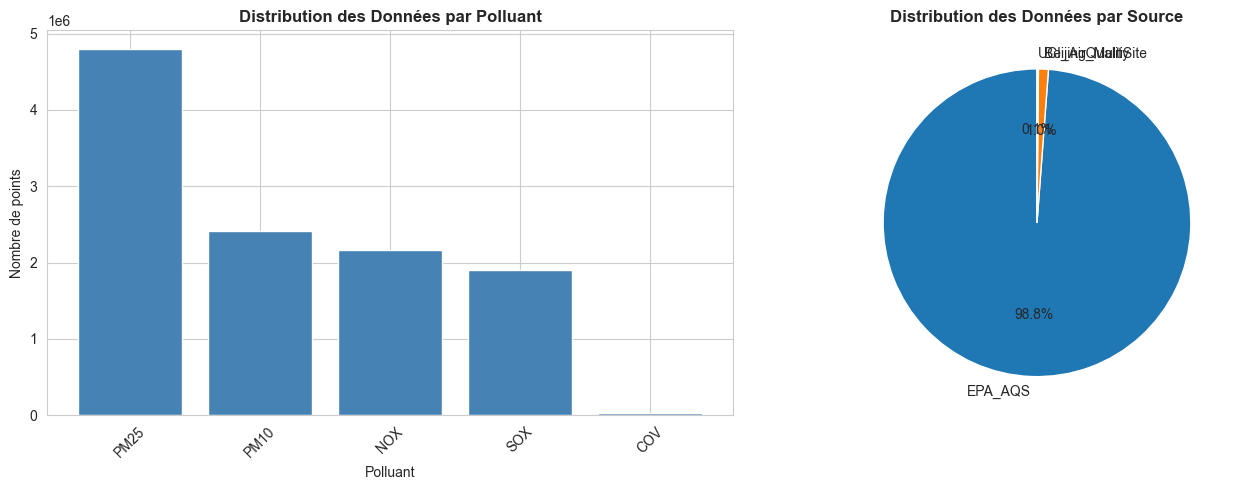

✅ Graphiques sauvegardés


In [21]:
# Visualisation 1: Couverture par polluant et source

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme: Nombre de points par polluant
pollutant_counts = merged_df['pollutant'].value_counts()
axes[0].bar(pollutant_counts.index.astype(str), pollutant_counts.values, color='steelblue')
axes[0].set_title('Distribution des Données par Polluant', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Polluant')
axes[0].set_ylabel('Nombre de points')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart: Distribution par source
source_counts = merged_df['source_name'].value_counts()
axes[1].pie(source_counts.values, labels=source_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribution des Données par Source', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(DATA_DIR / 'coverage_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Graphiques sauvegardés")

## Section 6: Statistiques Résumées et Export

In [15]:
# Statistiques par polluant

print("📊 STATISTIQUES PAR POLLUANT\n")

for pollutant in merged_df['pollutant'].unique():
    if pd.notna(pollutant):
        subset = merged_df[merged_df['pollutant'] == pollutant]['value']
        if len(subset) > 0:
            print(f"{pollutant}:")
            print(f"  Comptage: {len(subset)}")
            print(f"  Mean:  {subset.mean():.2f}")
            print(f"  Std:   {subset.std():.2f}")
            print(f"  Min:   {subset.min():.2f}")
            print(f"  Max:   {subset.max():.2f}")
            print()

📊 STATISTIQUES PAR POLLUANT

COV:
  Comptage: 32622
  Mean:  41.83
  Std:   50.21
  Min:   0.00
  Max:   645.22

NOX:
  Comptage: 31322
  Mean:  74.58
  Std:   87.74
  Min:   0.00
  Max:   874.00

PM10:
  Comptage: 23604
  Mean:  150.08
  Std:   18.56
  Min:   81.89
  Max:   240.12

PM25:
  Comptage: 23604
  Mean:  99.90
  Std:   13.79
  Min:   55.59
  Max:   174.26

SOX:
  Comptage: 23604
  Mean:  10.01
  Std:   9.70
  Min:   0.00
  Max:   97.26



In [16]:
# Exporter le dataset fusionné

output_path = DATA_DIR / 'raw_merged.csv'
# attempt atomic write; on PermissionError write to a timestamped fallback and update output_path
output_path.parent.mkdir(parents=True, exist_ok=True)
saved_path = output_path
try:
    tmp = output_path.with_suffix('.tmp')
    merged_df.to_csv(tmp, index=False)
    tmp.replace(output_path)  # atomic on most OS
    saved_path = output_path
except PermissionError:
    fallback = output_path.with_name(f"{output_path.stem}_{datetime.now().strftime('%Y%m%dT%H%M%S')}.csv")
    merged_df.to_csv(fallback, index=False)
    saved_path = fallback
    print(f"⚠️ Permission denied when writing {output_path}. Saved to fallback: {fallback}")
except Exception as e:
    print(f"✗ Erreur export: {e}")
    raise

# ensure subsequent prints reference the actual saved file
output_path = saved_path

print(f"✅ Dataset fusionné exporté à: {output_path}")
print(f"   Format: CSV")
print(f"   Taille: {len(merged_df):,} lignes × {len(merged_df.columns)} colonnes")
print(f"   Poids: {output_path.stat().st_size / 1024 / 1024:.2f} MB")

✅ Dataset fusionné exporté à: C:\Users\melik\Desktop\ia\data\raw_merged.csv
   Format: CSV
   Taille: 134,756 lignes × 14 colonnes
   Poids: 19.23 MB


In [17]:
# Exporter métadonnées et rapport

metadata = {
    'created_at': datetime.now().isoformat(),
    'total_rows': len(merged_df),
    'sources': merged_df['source_name'].unique().tolist() if not merged_df.empty else [],
    'pollutants': merged_df['pollutant'].unique().tolist() if not merged_df.empty else [],
    'date_range': {
        'min': merged_df['timestamp_utc'].min().isoformat() if not merged_df.empty and pd.notna(merged_df['timestamp_utc'].min()) else None,
        'max': merged_df['timestamp_utc'].max().isoformat() if not merged_df.empty and pd.notna(merged_df['timestamp_utc'].max()) else None
    },
    'quality_flags': {
        'duplicates_removed': n_duplicates if 'n_duplicates' in locals() else 0,
        'outliers_marked': merged_df['is_outlier'].sum() if 'is_outlier' in merged_df.columns else 0,
        'missing_values': missing_pct.to_dict() if 'missing_pct' in locals() and len(missing_pct) > 0 else {}
    },
    'source_distribution': merged_df['source_name'].value_counts().to_dict() if not merged_df.empty else {},
    'synthetic_data': {
        'beijing_synthetic_rows': beijing_canonical['synthetic'].sum() if 'synthetic' in beijing_canonical.columns else 0,
        'total_synthetic_percentage': (beijing_canonical['synthetic'].sum() / len(beijing_canonical) * 100) if not beijing_canonical.empty and 'synthetic' in beijing_canonical.columns else 0
    }
}

metadata_path = DATA_DIR / 'raw_merged_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"✅ Métadonnées exportées: {metadata_path}")
print(f"\n📊 RÉSUMÉ DATASET FUSIONNÉ:")
print(f"{'='*60}")
print(json.dumps(metadata, indent=2, default=str))

✅ Métadonnées exportées: C:\Users\melik\Desktop\ia\data\raw_merged_metadata.json

📊 RÉSUMÉ DATASET FUSIONNÉ:
{
  "created_at": "2026-05-19T12:15:37.872367",
  "total_rows": 134756,
  "sources": [
    "UCI_AirQuality",
    "Beijing_MultiSite"
  ],
  "pollutants": [
    "COV",
    "NOX",
    "PM10",
    "PM25",
    "SOX"
  ],
  "date_range": {
    "min": "2004-03-10T18:00:00",
    "max": "2017-12-28T22:00:00"
  },
  "quality_flags": {
    "duplicates_removed": "0",
    "outliers_marked": "219",
    "missing_values": {
      "wind_speed_ms": 100.0,
      "pressure_hpa": 12.419484104603876
    }
  },
  "source_distribution": {
    "Beijing_MultiSite": 118020,
    "UCI_AirQuality": 16736
  },
  "synthetic_data": {
    "beijing_synthetic_rows": "131400",
    "total_synthetic_percentage": 100.0
  }
}


## ✅ Prochaines étapes

1. **Notebook 02**: Nettoyage et preprocessing (`02_data_cleaning_preprocessing.ipynb`)
   - Interpolation des trous
   - Lissage EMA
   - Feature engineering
   - Output: `ia/data/cleaned_features.csv`

2. **Notebook 03**: Génération données synthétiques (`03_synthetic_data_generation.ipynb`)
   - CO2, PM10, COV synthétiques
   - Output: `ia/data/training_dataset.csv`

3. **Notebooks 04-07**: Entraînement modèles
   - Isolation Forest
   - LSTM (horizons 1h et 24h)